# BAGGING CLASSIFIER ALGORITHEM

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Parkinsons.csv')
df.head()

,Symptom,Alzheimer_Disease,Parkinsons_Disease,Overlapping_Symptom
0,Memory loss,Yes,No,No
1,Confusion,Yes,No,No
2,Difficulty in thinking,Yes,No,No
3,Disorientation,Yes,No,No
4,Tremors,No,Yes,No


In [3]:
df.columns

Index(['Symptom', 'Alzheimer_Disease', 'Parkinsons_Disease',
       'Overlapping_Symptom'],
      dtype='object')

In [4]:
df=df.dropna()

In [5]:
df.tail()

,Symptom,Alzheimer_Disease,Parkinsons_Disease,Overlapping_Symptom
21,Incontinence,Yes,Yes,No
22,Severe memory loss,Yes,No,No
23,Difficulty recognizing people,Yes,No,No
24,Visual-spatial difficulties,Yes,No,No
25,Rapid eye movement (REM) sleep disorder,No,Yes,No


In [6]:
df['Symptom'].value_counts()

Symptom
Memory loss                                1
Confusion                                  1
Visual-spatial difficulties                1
Difficulty recognizing people              1
Severe memory loss                         1
Incontinence                               1
Difficulty walking                         1
Loss of smell                              1
Agitation                                  1
Hallucinations                             1
Loss of facial expression                  1
Difficulty swallowing                      1
Difficulty in speaking                     1
Dementia                                   1
Memory problems                            1
Cognitive decline                          1
Sleep disturbances                         1
Mood changes                               1
Depression                                 1
Balance problems                           1
Slowness of movement                       1
Stiffness                                  1
Tr

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Symptom              26 non-null     object
 1   Alzheimer_Disease    26 non-null     object
 2   Parkinsons_Disease   26 non-null     object
 3   Overlapping_Symptom  26 non-null     object
dtypes: object(4)
memory usage: 960.0+ bytes


In [8]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

var = ['Symptom','Alzheimer_Disease','Parkinsons_Disease','Overlapping_Symptom']
  
for i in var:
    df[i] = le.fit_transform(df[i]).astype(int)

In [9]:
df['Symptom'].value_counts()

Symptom
16    1
3     1
25    1
8     1
20    1
13    1
10    1
15    1
0     1
12    1
14    1
9     1
6     1
4     1
17    1
2     1
21    1
18    1
5     1
1     1
22    1
23    1
24    1
11    1
7     1
19    1
Name: count, dtype: int64

In [10]:
x1 = df.drop(labels='Parkinsons_Disease', axis=1)
y1 = df.loc[:,'Parkinsons_Disease']

In [11]:
# import imblearn
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
# from sklearn.utils.metaestimators import if_delegate_has_method

ros =RandomOverSampler(random_state=42)
x,y=ros.fit_resample(x1,y1)
print("OUR DATASET COUNT         : ", Counter(y1))
print("OVER SAMPLING DATA COUNT  : ", Counter(y))

OUR DATASET COUNT         :  Counter({1: 19, 0: 7})
OVER SAMPLING DATA COUNT  :  Counter({0: 19, 1: 19})


In [12]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.10, random_state=42, stratify=y)
print("NUMBER OF TRAIN DATASET    : ", len(x_train))
print("NUMBER OF TEST DATASET      : ", len(x_test))
print("TOTAL NUMBER OF DATASET    : ", len(x_train)+len(x_test))

NUMBER OF TRAIN DATASET    :  34
NUMBER OF TEST DATASET      :  4
TOTAL NUMBER OF DATASET    :  38


In [13]:
print("NUMBER OF TRAIN DATASET    : ", len(y_train))
print("NUMBER OF TEST DATASET      : ", len(y_test))
print("TOTAL NUMBER OF DATASET    : ", len(y_train)+len(y_test))

NUMBER OF TRAIN DATASET    :  34
NUMBER OF TEST DATASET      :  4
TOTAL NUMBER OF DATASET    :  38


In [14]:
from sklearn.ensemble import BaggingClassifier

In [15]:
BAG = BaggingClassifier()
BAG.fit(x_train,y_train)

BaggingClassifier()

In [16]:
predicted = BAG.predict(x_test)

In [17]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,predicted)
print('THE CONFUSION MATRIX SCORE OF BAGGING CLASSIFIER:\n\n\n',cm)

THE CONFUSION MATRIX SCORE OF BAGGING CLASSIFIER:


 [[2 0]
 [0 2]]


In [18]:
from sklearn.model_selection import cross_val_score
accuracy = cross_val_score(BAG, x, y, scoring='accuracy')
print('THE CROSS VALIDATION TEST RESULT OF ACCURACY :\n\n\n', accuracy*100)

THE CROSS VALIDATION TEST RESULT OF ACCURACY :


 [ 87.5        100.         100.         100.          85.71428571]


In [19]:
from sklearn.metrics import accuracy_score
a = accuracy_score(y_test,predicted)
print("THE ACCURACY SCORE OF BAGGING CLASSIFIER IS :",a*100)

THE ACCURACY SCORE OF BAGGING CLASSIFIER IS : 100.0


In [20]:
from sklearn.metrics import hamming_loss
hl = hamming_loss(y_test,predicted)
print("THE HAMMING LOSS OF BAGGING CLASSIFIER IS :",hl*100)

THE HAMMING LOSS OF BAGGING CLASSIFIER IS : 0.0


In [21]:
from sklearn.metrics import precision_score
P = precision_score(y_test,predicted)
print("THE PRECISION SCORE OF BAGGING CLASSIFIER IS :",P*100)

THE PRECISION SCORE OF BAGGING CLASSIFIER IS : 100.0


In [22]:
from sklearn.metrics import recall_score
R = recall_score(y_test,predicted)
print("THE RECALL SCORE OF BAGGING CLASSIFIER IS :",R*100)

THE RECALL SCORE OF BAGGING CLASSIFIER IS : 100.0


In [23]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test,predicted)
print("THE PRECISION SCORE OF BAGGING CLASSIFIER IS :",f1*100)

THE PRECISION SCORE OF BAGGING CLASSIFIER IS : 100.0


THE CONFUSION MATRIX SCORE OF BAGGING CLASSIFIER:


[[2 0]
 [0 2]]


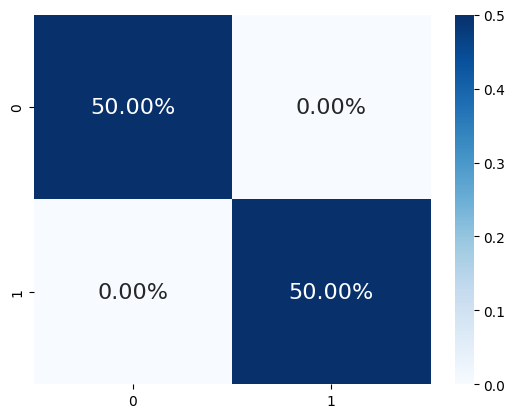

In [24]:
def plot_confusion_matrix(cm, title='THE CONFUSION MATRIX SCORE OF BAGGING CLASSIFIER\n\n', cmap=plt.cm.Blues):
    target_names=['']
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(target_names))
    plt.xticks(tick_marks, target_names, rotation=45)
    plt.yticks(tick_marks, target_names)
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

cm=confusion_matrix(y_test, predicted)
print('THE CONFUSION MATRIX SCORE OF BAGGING CLASSIFIER:\n\n')
print(cm)

sns.heatmap(cm/np.sum(cm), annot=True, cmap = 'Blues', annot_kws={"size": 16},fmt='.2%')
plt.show()

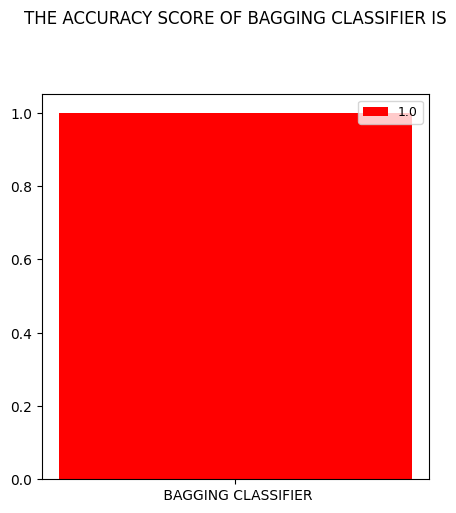

In [25]:
def graph():
    import matplotlib.pyplot as plt
    data=[a]
    alg=" BAGGING CLASSIFIER"
    plt.figure(figsize=(5,5))
    b=plt.bar(alg,data,color=("RED"))
    plt.title("THE ACCURACY SCORE OF BAGGING CLASSIFIER IS\n\n\n")
    plt.legend(b,data,fontsize=9)
graph()

In [26]:
import joblib
joblib.dump(BAG, 'model_1.pkl')

['model_1.pkl']